# Algorithme d'acquisition GNSS

Ce notebook presente les fonctions, l'execution et l'analyse des resultats.

## 1. Fonctions preparatoires

### 1.1 Representation 3D de la correlation

Cette fonction represente la surface Doppler/phase afin d'identifier le pic de correlation.

In [1]:
# Visualisation 3D de la correlation.
def plot_3d_correlation_paper(

        Z,

        x_axis=None,

        y_axis=None,

        title="3D Correlation Surface",

        xlabel="Code Delay (chips)",

        ylabel="Doppler (Hz)",

        zlabel="Correlation Power",

        elev=30,

        azim=-130,

        save_path=None

    ):

    """

    Plot 3D publication-ready (IEEE style).

    """
    import matplotlib as mpl

    # === Style scientifique propre ===

    mpl.rcParams.update({

        "font.family": "serif",

        "font.size": 12,

        "axes.labelsize": 12,

        "axes.titlesize": 13,

        "xtick.labelsize": 10,

        "ytick.labelsize": 10,

        "legend.fontsize": 10,

        "figure.dpi": 120

    })


    if x_axis is None:

        x_axis = np.arange(Z.shape[1])



    if y_axis is None:

        y_axis = np.arange(Z.shape[0])

    X, Y = np.meshgrid(x_axis, y_axis)

    fig = plt.figure(figsize=(8, 6))

    ax = fig.add_subplot(111, projection='3d')

#     # === Colormap scientifique ===
#     surf = ax.plot_surface(
#         X, Y, Z,
#         cmap='viridis',   # perceptuellement uniforme
#         linewidth=0,
#         antialiased=True,
#         alpha=0.95
#     )

    surf = ax.plot_surface(

        X, Y, Z,

        cmap='jet', # ou turbo pour publication scient.

        rstride=1,

        cstride=1,

        linewidth=0,

        antialiased=False,

        alpha=1.0

    )

    # === Colorbar propre ===
    cbar = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=18, pad=0.1)
    cbar.set_label("Correlation Power")
    
    # === Labels ===
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel(zlabel)
    ax.set_title(title)

    # === Pic marqué proprement ===
    idx = np.argmax(Z)
    row, col = np.unravel_index(idx, Z.shape)
    peak = Z[row, col]

#     #Ajoute une ligne verticale vers le pic

#     ax.plot(

#         [x_axis[col], x_axis[col]],

#         [y_axis[row], y_axis[row]],

#         [0, peak],

#         color='pink',

#         linewidth=10

#     )

     # Cylindre mince autour du pic

    theta = np.linspace(0, 2*np.pi, 40)

    radius = (x_axis[1] - x_axis[0]) * 0.5  # largeur fine

    xc = x_axis[col] + radius * np.cos(theta)

    yc = y_axis[row] + radius * np.sin(theta)

    for i in range(len(theta)):

        ax.plot(

            [xc[i], xc[i]],

            [yc[i], yc[i]],

            [0, peak],

            color='red',

            linewidth=2

        )
 

#     ax.scatter(

#         x_axis[col],

#         y_axis[row],

#         peak,

#         #color='red',        # Couleur vive

#         edgecolor='black',  # Contour noir pour contraste

#         s=120,              # Taille plus grande

#         #marker='o',

#         depthshade=False,   # IMPORTANT : enlève effet 3D sombre

#         zorder=10,          # Passe au-dessus de la surface

#         label='Peak'

        

# #         x_axis[col],

# #         y_axis[row],

# #         peak,

# #         color='black',

# #         s=40,

# #         marker='o',

# #         label='Peak'

#     )

    ax.legend()
    ax.view_init(elev=elev, azim=azim)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Figure sauvegardée : {save_path}")
    plt.show()

In [2]:
# Export des matrices, figures et resumes.
# =========================
# SAVE MATRIX
# =========================
def save_results_matrix(method, satellite, corr_matrix, doppler_axis, phase_axis):

    os.makedirs("results", exist_ok=True)
    filename = f"results/{method}_PRN{satellite}_matrix.csv"

    df = pd.DataFrame(

        corr_matrix,
        index=doppler_axis,
        columns=phase_axis
    )

    df.index.name = "Doppler_Hz"
    df.columns.name = "Code_Phase"
    df.to_csv(filename)

    print(f"Matrice sauvegardée : {filename}")

    return filename

# =========================
# SAVE PLOT
# =========================
def save_plot(method,
              satellite,
              corr_matrix,
              doppler_axis,
              phase_axis):

    os.makedirs("results", exist_ok=True)
    filename = f"results/{method}_PRN{satellite}_plot3D.png"

    plot_3d_correlation_paper(

        Z=corr_matrix,

        x_axis=phase_axis,

        y_axis=doppler_axis,

        title=f"{method} GNSS Acquisition - PRN {satellite}",

        save_path=filename

    )
    return filename

# =========================
# SAVE SUMMARY FILE
# =========================
def save_summary_file(method,
                      satellite,
                      doppler,
                      phase,
                      peak,
                      peak_ratio,
                      variance,
                      time_s,
                      memory_mb,
                      energy_j,
                      detected,
                      matrix_file,
                      plot_file):

    from datetime import datetime
    os.makedirs("results", exist_ok=True)
    
    now = datetime.now()
    
    filename = f"results/{method}_PRN{satellite}_summary.txt"
    with open(filename, "w") as f:
        
        f.write("===== GNSS Acquisition Results =====\n\n")

        f.write(f"Satellite      : {satellite}\n")

        f.write(f"Méthode        : {method}\n")

        f.write(f"Date           : {now.strftime('%Y-%m-%d')}\n")

        f.write(f"Heure          : {now.strftime('%H:%M:%S')}\n\n")

        f.write(f"Doppler (Hz)   : {doppler}\n")

        f.write(f"Code Phase     : {phase}\n\n")

        f.write(f"Peak           : {peak}\n")

        f.write(f"Peak Ratio     : {peak_ratio}\n")

        f.write(f"Variance       : {variance}\n\n")

        f.write(f"Execution Time : {time_s} s\n")

        f.write(f"Memory Usage   : {memory_mb} MB\n")

        f.write(f"Energy Est.    : {energy_j} J\n\n")

        f.write(f"Satellite Detected : {'YES' if detected else 'NO'}\n\n")

        f.write(f"Correlation Matrix : {matrix_file}\n")

        f.write(f"3D Plot            : {plot_file}\n")

    print("Summary sauvegardé :", filename)

    return filename

# =========================
# SAVE EVERYTHING
# =========================
def save_acquisition_results(method,
                             satellite,
                             corr_matrix,
                             doppler_axis,
                             phase_axis,
                             doppler_est,
                             phase_est,
                             peak,
                             peak_ratio,
                             variance,
                             time_s,
                             memory_mb,
                             energy_j,
                             detected):

    matrix_file = save_results_matrix(

        method,
        satellite,
        corr_matrix,
        doppler_axis,
        phase_axis
    )

    plot_file = save_plot(

        method,
        satellite,
        corr_matrix,
        doppler_axis,
        phase_axis
    )

    summary_file = save_summary_file(

        method,
        satellite,
        doppler_est,
        phase_est,
        peak,
        peak_ratio,
        variance,
        time_s,
        memory_mb,
        energy_j,
        detected,
        matrix_file,
        plot_file

    )
    return summary_file


In [3]:
# Mesure du temps, de la memoire et de l'energie.
def measure_complete(func, *args, interval=0.1):

    P_idle = 0.3
    P_max  = 1.8

    energy = 0
    running = True
    memory_peak = 0

    def sampler():
        nonlocal energy, memory_peak

        while running:

            current, peak = tracemalloc.get_traced_memory()
            memory_peak = max(memory_peak, peak)

            cpu = psutil.cpu_percent(interval=interval) / 100.0
            power = P_idle + (P_max - P_idle) * cpu

            energy += power * interval

    tracemalloc.start()

    thread = threading.Thread(target=sampler)
    thread.start()

    start = time.perf_counter()

    result = func(*args)

    elapsed = time.perf_counter() - start

    running = False
    thread.join()

    tracemalloc.stop()

    memory_mb = memory_peak / (1024 * 1024)

    return result, elapsed, memory_mb, energy


# Ajoute une ligne de resultat dans le tableau comparatif global.
def add_result(method,
               satellite,
               doppler,
               phase,
               peak,
               peak_ratio,
               variance,
               time_s,
               memory_mb,
               energy_j,
               avg_power_w,
               detected):

    global results_table

    results_table.append({
        "Method": method,
        "PRN": satellite,
        "Doppler (Hz)": doppler,
        "Code Phase": phase,
        "Peak": peak,
        "Peak Ratio": peak_ratio,
        "Variance": variance,
        "Time (s)": round(time_s,4) if time_s else None,
        "Memory (MB)": round(memory_mb,2) if memory_mb else None,
        "Energy (J)": round(energy_j,3) if energy_j else None,
        "Power (W)": round(avg_power_w,3) if avg_power_w else None,
        "Detected": detected
    })


def benchmark_method(method_name, func, satellite, signal, prn):

    result, elapsed, memory_mb, energy_j = measure_complete(
        func, signal, prn, satellite
    )
    avg_power_w = (energy_j / elapsed) if elapsed > 1e-12 else 0.0

    # ========================
    # TSA
    # ========================
    if method_name == "TSA":

        doppler, phase, peak, variance, corr_matrix, detected = result
        
        if corr_matrix is None:
            peak_ratio = 0
        else:
            mean_corr = np.mean(corr_matrix)
            peak_ratio = peak / mean_corr if mean_corr > 1e-12 else 0

        save_acquisition_results(
            method=method_name,
            satellite=satellite,
            corr_matrix=corr_matrix,
            doppler_axis=None,
            phase_axis=PHASE_AXIS,
            doppler_est=doppler,
            phase_est=phase,
            peak=peak,
            peak_ratio=peak_ratio,
            variance=variance,
            time_s=elapsed,
            memory_mb=memory_mb,
            energy_j=energy_j,
            detected=detected
        )

        add_result(
            method_name,
            satellite,
            doppler,
            phase,
            peak,
            peak_ratio,
            variance,
            elapsed,
            memory_mb,
            energy_j,
            avg_power_w,
            detected
        )

    # ========================
    # SERIAL
    # ========================
    elif method_name == "SA":

        doppler, phase, peak, corr_matrix, detected = result

        mean_corr = np.mean(corr_matrix)
        peak_ratio = peak / mean_corr if mean_corr > 1e-12 else 0

        save_acquisition_results(
            method=method_name,
            satellite=satellite,
            corr_matrix=corr_matrix,
            doppler_axis= np.arange(-10000,10001,250),
            phase_axis=PHASE_AXIS,
            doppler_est=doppler,
            phase_est=phase,
            peak=peak,
            peak_ratio=peak_ratio,
            variance=None,
            time_s=elapsed,
            memory_mb=memory_mb,
            energy_j=energy_j,
            detected=detected
        )

        add_result(
            method_name,
            satellite,
            doppler,
            phase,
            peak,
            peak_ratio,
            None,
            elapsed,
            memory_mb,
            energy_j,
            avg_power_w,
            detected
        )

    # ========================
    # FFT
    # ========================
    elif method_name == "FFT":

        doppler, phase, peak, corr_matrix, detected = result

        mean_corr = np.mean(corr_matrix)
        peak_ratio = peak / mean_corr if mean_corr > 1e-12 else 0

        save_acquisition_results(
            method=method_name,
            satellite=satellite,
            corr_matrix=corr_matrix,
            doppler_axis=np.arange(-10000,10001,250),
            phase_axis=PHASE_AXIS,
            doppler_est=doppler,
            phase_est=phase,
            peak=peak,
            peak_ratio=peak_ratio,
            variance=None,
            time_s=elapsed,
            memory_mb=memory_mb,
            energy_j=energy_j,
            detected=detected
        )

        add_result(
            method_name,
            satellite,
            doppler,
            phase,
            peak,
            peak_ratio,
            None,
            elapsed,
            memory_mb,
            energy_j,
            avg_power_w,
            detected
        )


def print_comparison_table():

    if len(results_table) == 0:
        print("\nAucun résultat")
        return

    df = pd.DataFrame(results_table)

    print("\n====================================================")
    print("        GNSS ACQUISITION BENCHMARK")
    print("====================================================")

    print(df.to_string(index=False))

    print("====================================================\n")


def export_results_table(output_dir="results", base_name="benchmark_all_methods"):
    if len(results_table) == 0:
        print("Aucun resultat a exporter.")
        return None, None

    os.makedirs(output_dir, exist_ok=True)
    df = pd.DataFrame(results_table)

    csv_path = os.path.join(output_dir, f"{base_name}.csv")
    json_path = os.path.join(output_dir, f"{base_name}.json")

    df.to_csv(csv_path, index=False)
    df.to_json(json_path, orient="records", indent=2, force_ascii=False)

    print(f"Export global CSV : {csv_path}")
    print(f"Export global JSON : {json_path}")

    return csv_path, json_path

## 2. Procedure d'acquisition et comparaison des methodes

Cette section regroupe les constantes, les fonctions d'acquisition et la comparaison des methodes (`FFT`, `SA`, `Coarse`, `Fine`).

### 2.1 Demarche d'execution

1. Definir les constantes et fonctions d'acquisition.
2. Executer les methodes a comparer.
3. Verifier les sorties generees dans `results`.


=== Initialisation GNSS ===
Numéro satellite : 25

     GNSS ACQUISITION FRAMEWORK     
Satellite chargé : PRN 25
------------------------------------

ACQUISITION
1 - TSA Grossier
2 - TSA Fin
3 - TSA complet
4 - Serial Acquisition
5 - FFT Acquisition

BENCHMARK
6 - Benchmark complet
7 - Tableau comparatif

SYSTEM
8 - Changer satellite
0 - Quitter

Votre choix : 6

=== BENCHMARK COMPLET ===

========== TSA ACQUISITION ==========

========== COARSE SEARCH ==========

>>> COARSE SUCCESS <<<
Doppler offset : -1500.0
Phase coarse : 150
Peak coarse : 30707.64701012564
Variance : 0.07607086404471824
Peak1: 30707.64701012564
Peak2: 27726.699722890793
Ratio: 1.1075117961036602

➡ Lancement Fine Search...


========== FINE SEARCH ==========

========== FINE SEARCH ==========
Doppler offset initial (grossier): -1500.0 Hz
Recherche fine sur les offsets: [-2500 -2250 -2000 -1750 -1500 -1250 -1000  -750  -500  -250     0   250
   500   750  1000  1250  1500  1750  2000  2250  2500]
Fréquences abso

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Figure sauvegardée : results/TSA_PRN25_plot3D.png


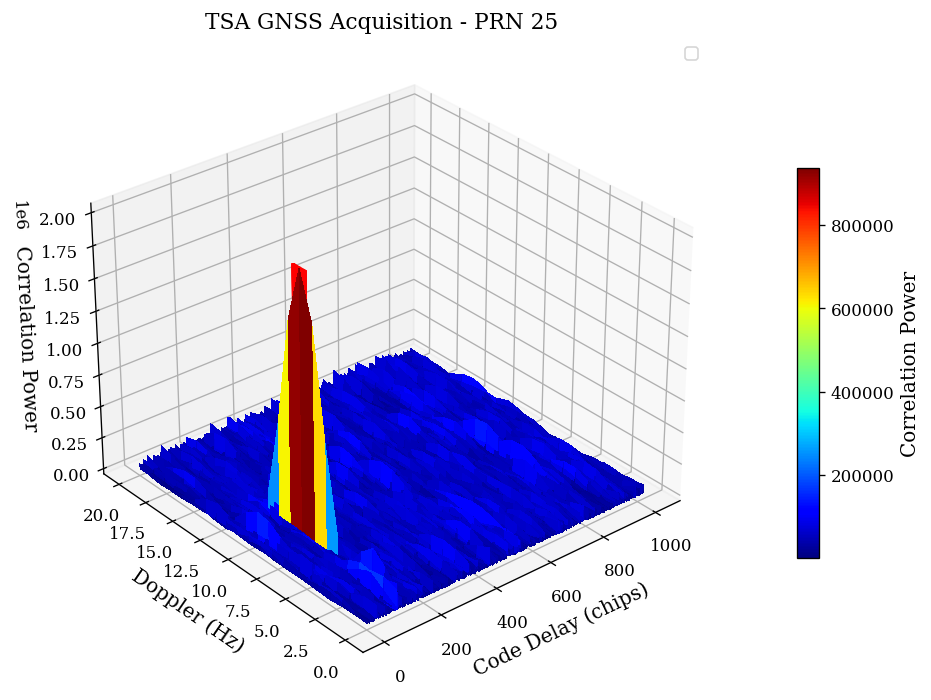

Summary sauvegardé : results/TSA_PRN25_summary.txt

Début de la Serial Acquisition classique...

--- Résultat acquisition SERIAL ---
Satellite détecté : 1
Pic de corrélation = 2028801.92
Moyenne corrélation = 25005.61
Peak Ratio = 81.13
Décalage PRN = 150
Doppler estimé = -1750 Hz
Serial achevée - Temps écoulé : 1.140462e+02 s
Peak1: 2028801.917539093
Peak2: 1675736.1926856597
Ratio: 1.2106929040468977
Matrice sauvegardée : results/SA_PRN25_matrix.csv


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Figure sauvegardée : results/SA_PRN25_plot3D.png


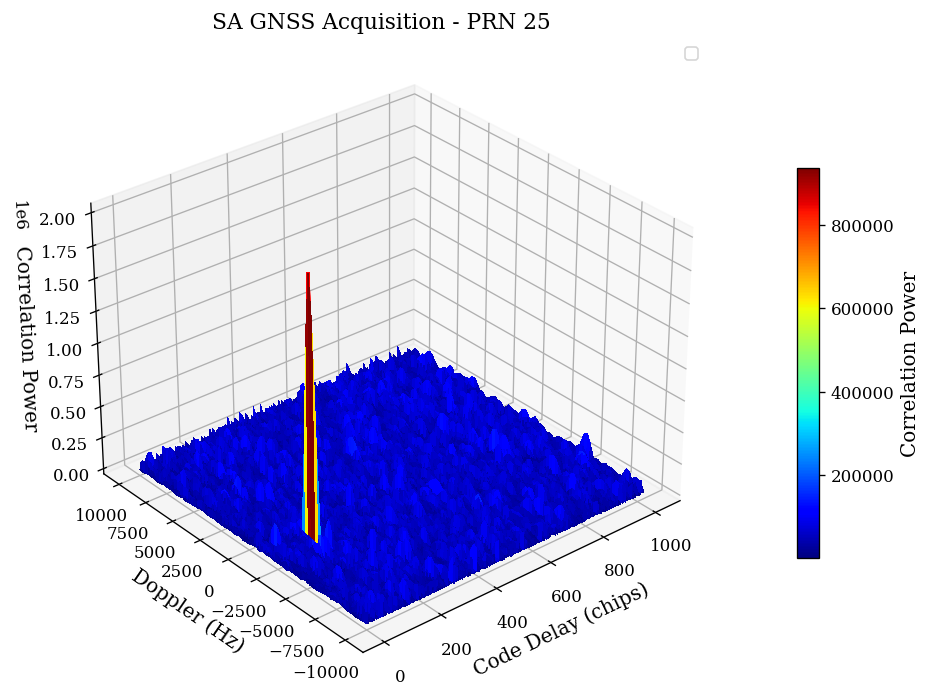

Summary sauvegardé : results/SA_PRN25_summary.txt

--- Résultat acquisition FFT ---
Pic de corrélation = 69618967.99
Décalage PRN =  151
Doppler estimé = -1750 Hz
Le temps écoulé est de  2.926858e+00 s
fft achevée - Temps écoulé : 2.926858e+00 s
Peak1: 69618967.99182539
Peak2: 55692519.3223395
Ratio: 1.2500595921847566
Matrice sauvegardée : results/FFT_PRN25_matrix.csv


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Figure sauvegardée : results/FFT_PRN25_plot3D.png


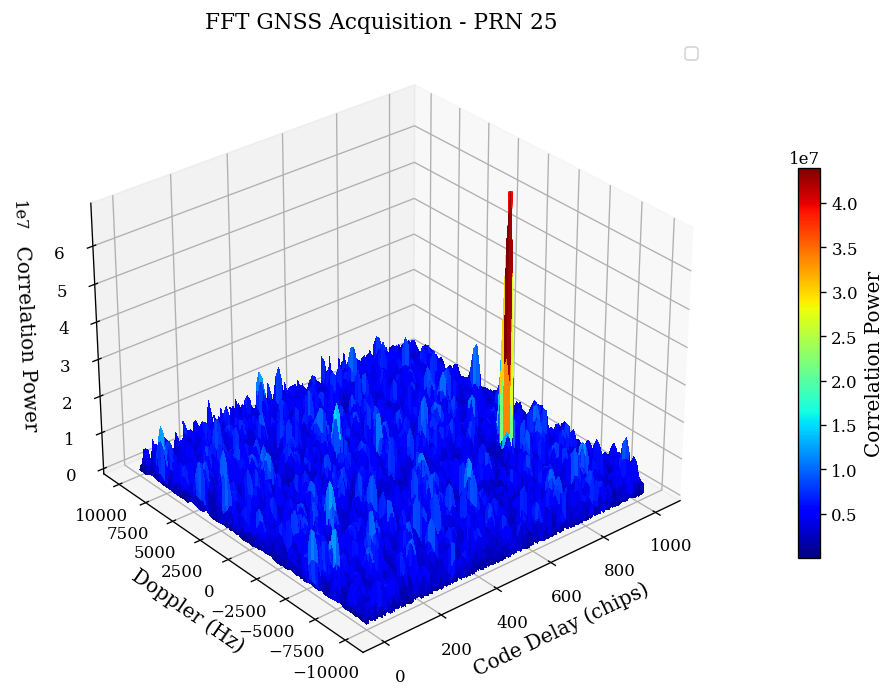

Summary sauvegardé : results/FFT_PRN25_summary.txt

        GNSS ACQUISITION BENCHMARK
Method  PRN  Doppler (Hz)  Code Phase         Peak  Peak Ratio  Variance  Time (s)  Memory (MB)  Energy (J)  Power (W)  Detected
   TSA   25       -1750.0         150 2.028802e+06   80.362101  0.212608  111.4925       196.65      94.163      0.845         1
    SA   25       -1750.0         150 2.028802e+06   81.133867       NaN  114.1154       188.40     105.482      0.924         1
   FFT   25       -1750.0         151 6.961897e+07   40.455840       NaN    2.9443         2.02       3.122      1.060         1

Export global CSV : results/benchmark_all_methods.csv
Export global JSON : results/benchmark_all_methods.json

Temps écoulé : 828.0116176605225 s

     GNSS ACQUISITION FRAMEWORK     
Satellite chargé : PRN 25
------------------------------------

ACQUISITION
1 - TSA Grossier
2 - TSA Fin
3 - TSA complet
4 - Serial Acquisition
5 - FFT Acquisition

BENCHMARK
6 - Benchmark complet
7 - Tableau com

In [ ]:
# Bloc principal: imports, constantes et benchmark.
# `results_table` centralise les resultats de chaque methode.
import tracemalloc
import psutil

import threading

import time

import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

import os

results_table = []

# =========================
# === CONSTANTES SYSTEME ==
# =========================

FS = 11.999e6

NB_ECHANTILLONS = 11999

NB_PHASES = 1023

NB_DOPPLER_COARSE = 41

NB_DOPPLER_FINE = 21

FREQUENCE_CENTRALE = 3.563e6

DOPPLER_BIN_COARSE = 500

DOPPLER_BIN_FINE = 250

SEUIL_VARIANCE_COARSE = 0.039

SEUIL_VARIANCE_FINE = 0.18

SHIFTS = np.floor(np.arange(NB_PHASES) * NB_ECHANTILLONS / NB_PHASES).astype(int)

PHASE_AXIS = np.arange(NB_PHASES)

# =========================
# === save matrix
# =========================
def save_results_matrix(method, satellite, corr_matrix, doppler_axis, phase_axis):

    os.makedirs("results", exist_ok=True)

    filename = f"results/{method}_PRN{satellite}_matrix.csv"

    df = pd.DataFrame(

        corr_matrix,
        index=doppler_axis,
        columns=phase_axis
    )

    df.index.name = "Doppler_Hz"

    df.columns.name = "Code_Phase"

    df.to_csv(filename)

    print(f"Matrice sauvegardée : {filename}")

# =========================
# === save results
# =========================
def save_acquisition_result(method, satellite, doppler, phase, peak, variance):

    filename = f"results/acquisitions/{method}_results.csv"

    row = {

        "Satellite": satellite,

        "Doppler": doppler,

        "Phase": phase,

        "Peak": peak,

        "Variance": variance
    }

    df = pd.DataFrame([row])

    if os.path.exists(filename):

        df.to_csv(filename, mode="a", header=False, index=False)

    else:

        df.to_csv(filename, index=False)

    print(f"Résultat sauvegardé : {filename}")

# =========================
# === LECTURE DES FICHIERS
# =========================
def charger_signal(path):
    data = np.loadtxt(path, delimiter=',')
    return data

def charger_prn(satellite):
    filename = f"PRN-{satellite}.csv"
    try:
        prn = np.loadtxt(filename, delimiter=',')
        return prn
    except:
        print("PRN introuvable")
        return None

# =========================
# VARIANCE STSA
# =========================
def variance_stsa(low, high):
    r = low / high
    m = (1 + r) / 2
    return 0.5 * ((1 - m)**2 + (r - m)**2)

# =========================
# INSERT PEAK
# =========================
def insert_peak(ListOfPeaks, peak, max_size):

    if len(ListOfPeaks) < max_size:
        ListOfPeaks.append(peak)
        return

    min_peak = min(ListOfPeaks, key=lambda x: x[2])

    if peak[2] > min_peak[2]:
        ListOfPeaks.remove(min_peak)

        ListOfPeaks.append(peak)
        
# =========================
# PRECOMPUTE PRN PHASES
# =========================
def precompute_prn_shifts(prn, shifts, N):

    prn_shifted = np.empty((NB_PHASES, N), dtype=np.float32)
    for tau in range(NB_PHASES):
        prn_shifted[tau] = np.roll(prn, -shifts[tau])
    return prn_shifted

# =========================
# COARSE SEARCH
# =========================
def suivi_gps_grossier(signal, prn, satellite, precision=8):

    print("\n========== COARSE SEARCH ==========")
    
    Ts = 1 / FS
    N = NB_ECHANTILLONS
    MaxNumPeaks = 5
    higherLowerPeaks = [1]

    doppler_offsets = DOPPLER_BIN_COARSE * (

            np.arange(NB_DOPPLER_COARSE) - (NB_DOPPLER_COARSE - 1)/2
        )

# =================================
# Pré calcul des porteuses Doppler
# ==================================
#     n_full = np.arange(N)

#     doppler_carriers = [
#         np.exp(-1j * 2 * np.pi * (FREQUENCE_CENTRALE + fd) * n_full * Ts)
#         for fd in doppler_offsets
#     ]

    doppler_carriers = DOPPLER_CARRIERS_COARSE

    # shifts = np.floor(np.arange(NB_PHASES) * N / NB_PHASES).astype(int)
    shifts = SHIFTS

   
    prn_shifted = PRN_SHIFTED

#     prn_shifted = precompute_prn_shifts(prn, shifts, N)

    for index_pas in range(precision):

        ListOfPeaks = []
#         n = np.arange(index_pas, N, precision)
        n = STSA_INDICES[index_pas]
        sig = signal[n]

        prn_sub = prn_shifted[:, n]

# =====  BOUCLE DOPPLER SIMPLE =====
        carriers = np.array([doppler_carriers[d][n] for d in range(len(doppler_offsets))])

        dataMix = carriers * sig

        corr_complex = prn_sub @ dataMix.T

        power = np.abs(corr_complex)**2


        phase_idx = np.argmax(power, axis=0)

        peak_power = power[phase_idx, np.arange(power.shape[1])]


        for d, fd in enumerate(doppler_offsets):

            insert_peak(
                ListOfPeaks,
                (fd, phase_idx[d], peak_power[d]),
                MaxNumPeaks
            )

#         for d, fd in enumerate(doppler_offsets):

#             fc = FREQUENCE_CENTRALE + fd

# #             carrier = np.exp(-1j * 2 * np.pi * fc * n * Ts)
#             carrier = doppler_carriers[d][n]

#             dataMix = sig * carrier

#             corr_complex = prn_sub @ dataMix

#             power = np.abs(corr_complex)**2

#             phase_idx = np.argmax(power)

#             peak_power = power[phase_idx]

#             insert_peak(

#                 ListOfPeaks,

#                 (fd, phase_idx, peak_power),

#                 MaxNumPeaks

#             )

        if len(ListOfPeaks) >= 2:

            ListOfPeaks.sort(key=lambda x: x[2])

            lowest = ListOfPeaks[0][2]

            highest = ListOfPeaks[-1][2]

            ratio = lowest / highest

            higherLowerPeaks.append(ratio)

            if len(higherLowerPeaks) > precision + 1:

                higherLowerPeaks.pop(0)

            var = np.var(higherLowerPeaks)

            if var > SEUIL_VARIANCE_COARSE:

                best_peak = max(ListOfPeaks, key=lambda x: x[2])

                doppler_offset = best_peak[0]

                phase = best_peak[1]

                print("\n>>> COARSE SUCCESS <<<")

                print("Doppler offset :", doppler_offset)

                print("Phase coarse :", phase)

                print("Peak coarse :", best_peak[2])

                print("Variance :", var)
                ListOfPeaks.sort(key=lambda x: x[2])

                peak1 = ListOfPeaks[-1][2]
                peak2 = ListOfPeaks[-2][2]

                print("Peak1:", peak1)
                print("Peak2:", peak2)
                print("Ratio:", peak1/peak2)

                print("\n➡ Lancement Fine Search...\n")

                return suivi_gps_fin(signal, prn, doppler_offset, satellite)

    print("❌ Coarse non validée")

    return None

# =========================
# FINE SEARCH
# =========================
def suivi_gps_fin(signal, prn, doppler_offset, satellite):

    print("\n========== FINE SEARCH ==========")
    print(f"\n========== FINE SEARCH ==========")
    print(f"Doppler offset initial (grossier): {doppler_offset} Hz")
    
    # Calcul des offsets à tester
    doppler_offsets_rel = np.arange(
        -(NB_DOPPLER_FINE//2)*DOPPLER_BIN_FINE,
        (NB_DOPPLER_FINE//2)*DOPPLER_BIN_FINE + 1,
        DOPPLER_BIN_FINE
    )
    
    doppler_offsets_abs = doppler_offset + doppler_offsets_rel
    print(f"Recherche fine sur les offsets: {doppler_offsets_rel}")
    print(f"Fréquences absolues testées: {doppler_offsets_abs}")

    Ts = 1 / FS

    N = NB_ECHANTILLONS

    n = np.arange(N)  

    shifts = SHIFTS
#     shifts = np.floor(np.arange(NB_PHASES) * N / NB_PHASES).astype(int)

    # -------------------------
    # Doppler range
    # -------------------------
    doppler_offsets = np.arange(

        doppler_offset - (NB_DOPPLER_FINE//2)*DOPPLER_BIN_FINE,

        doppler_offset + (NB_DOPPLER_FINE//2)*DOPPLER_BIN_FINE + 1,

        DOPPLER_BIN_FINE

    )

    # -------------------------
    # PRN variantes
    # -------------------------
#     prn_half_plus  = 0.5 * (prn + np.roll(prn, -1))
#     prn_half_minus = 0.5 * (prn + np.roll(prn, 1))

    prn_variants = [
        prn,
        prn_half_plus,
        prn_half_minus
    ]

    # -------------------------
    # PRECOMPUTE MATRICES
    # -------------------------
    prn_matrices = [

        PRN_SHIFTED,

        PRN_SHIFTED_HALF_PLUS,

        PRN_SHIFTED_HALF_MINUS

    ]
#     prn_matrices = [

#         PRN_SHIFTED,

#         precompute_prn_shifts(prn_half_plus, SHIFTS, N),

#         precompute_prn_shifts(prn_half_minus, SHIFTS, N)

#     ]

    # -------------------------
    # STSA structures
    # -------------------------
    MaxNumPeaksFS = 16

    ListOfPeaksFS = [[], [], []]

    higherLowerPeaks1 = [1]

    higherLowerPeaks2 = [1]

    higherLowerPeaks3 = [1]

    corr_matrix = np.zeros((len(doppler_offsets), NB_PHASES))

    # -------------------------
    # SEARCH
    # -------------------------
    for d, fd in enumerate(doppler_offsets):
        
#         carrier = DOPPLER_CARRIERS_FINE[d]

        carrier = np.exp(-1j * 2 * np.pi *(FREQUENCE_CENTRALE +fd ) * n * Ts)
        dataMix = signal * carrier
        
#         fc = FREQUENCE_CENTRALE + fd

#         carrier = np.exp(-1j * 2 * np.pi * fc * n * Ts)

#         dataMix = signal * carrier

        for p, prn_matrix in enumerate(prn_matrices):

            corr_complex = prn_matrix @ dataMix

            power = np.abs(corr_complex)**2

            if p == 0:   # PRN original uniquement

                corr_matrix[d,:] = power
            phase_idx = np.argmax(power)
            peak_power = power[phase_idx]

            insert_peak(

                ListOfPeaksFS[p],

                (fd, phase_idx, peak_power),

                MaxNumPeaksFS

            )

    # -------------------------
    # STSA variance
    # -------------------------



    for i, peaks in enumerate(ListOfPeaksFS):

        peaks.sort(key=lambda x: x[2])

        low = peaks[0][2]

        high = peaks[-1][2]

        ratio = low / high

        if i == 0:

            higherLowerPeaks1.append(ratio)

        elif i == 1:

            higherLowerPeaks2.append(ratio)

        else:

            higherLowerPeaks3.append(ratio)

    var1 = np.var(higherLowerPeaks1)

    var2 = np.var(higherLowerPeaks2)

    var3 = np.var(higherLowerPeaks3)

    HigherVariance = max(var1, var2, var3)

    # -------------------------
    # Best peak
    # -------------------------
    best_peak = None

    best_power = 0

    for peaks in ListOfPeaksFS:

        if peaks:

            peak = max(peaks, key=lambda x: x[2])

            if peak[2] > best_power:

                best_peak = peak

                best_power = peak[2]

    doppler_fin = best_peak[0]
    phase = best_peak[1]


    # Dans suivi_gps_fin, après le calcul des fréquences
    print(f"Vérification FREQUENCE_CENTRALE = {FREQUENCE_CENTRALE} Hz")
    print(f"Fréquence échantillonnage FS = {FS} Hz")
    print(f"Fréquence de Nyquist = {FS/2} Hz")

    # Vérifiez si vos fréquences dépassent Nyquist
    freq_max = FREQUENCE_CENTRALE + max(doppler_offsets_abs)
    freq_min = FREQUENCE_CENTRALE + min(doppler_offsets_abs)
    print(f"Fréquences testées: {freq_min/1e6:.2f} MHz à {freq_max/1e6:.2f} MHz")
    print(f"Limite Nyquist: {FS/2/1e6:.2f} MHz")

    if freq_max > FS/2 or freq_min < 0:
        print("⚠️  ALIASING DÉTECTÉ ! Certaines fréquences dépassent Nyquist")

    # -------------------------
    # AFFICHAGE
    # -------------------------
    print("\n>>> FINE RESULT <<<")

    print("Doppler offset :", doppler_fin)

    print("Phase fine :", phase)

    print("Peak :", best_power)

    print("Variance :", HigherVariance)

    flat = corr_matrix.flatten()
    top2 = np.partition(flat, -2)[-2:]

    print("Peak1:", top2[1])
    print("Peak2:", top2[0])
    print("Ratio:", top2[1]/top2[0])

    # -------------------------
    # VALIDATION
    # -------------------------

    if HigherVariance > SEUIL_VARIANCE_FINE:

        print("✅ Acquisition confirmée")

        return doppler_fin, phase, best_power, HigherVariance, corr_matrix, 1

    else:

        print("❌ Acquisition non confirmée")

        return doppler_fin, phase, best_power, HigherVariance, corr_matrix, 0  

# =========================
# TSA COMPLET
# =========================
def tsa_acquisition(signal, prn, satellite):

    print("\n========== TSA ACQUISITION ==========")

    coarse = suivi_gps_grossier(signal, prn, satellite)

    if coarse is None:
        return 0, 0, 0, 0, None, 0

    return coarse

# =========================
# === SERIAL ACQUISITION
# =========================
#--------------SA Version 4 ------------------------

def classical_serial_acquisition(signal, prn, satellite):

    print("\nDébut de la Serial Acquisition classique...")

    start_time = time.time()

    N = NB_ECHANTILLONS

    Ts = 1 / FS

    n = np.arange(N)

    doppler_range = np.arange(-10000, 10001, 250)

    Nd = len(doppler_range)

    # ==============================
    # 2 Pré-calcul shifts MATLAB
    # ==============================

    shifts = SHIFTS

    prn_shifted = PRN_SHIFTED



#     # ==============================
#     # 2 Pré-calcul PRN décalés
#     # ==============================
#     prn_shifted = np.zeros((NB_PHASES, N))



#     for tau in range(NB_PHASES):
# #         prn_shifted[tau] = np.roll(prn, shifts[tau])
# #---------------Option correlation inverse pour obtenir la bonne phase--------------
#         prn_shifted[tau] = np.roll(prn, -shifts[tau])        



    # ==============================
    # 3 Matrice corrélation
    # ==============================

    corr_matrix = np.zeros((Nd, NB_PHASES))

    # ==============================
    # 4 Boucle Doppler uniquement
    # ==============================

    for k, fd in enumerate(doppler_range):

        carrier = np.exp(-1j * 2 * np.pi * (FREQUENCE_CENTRALE + fd) * n * Ts)

        dataMix = signal * carrier

        # Corrélation vectorisée sur toutes les phases

        corr_complex = (prn_shifted @ dataMix) 

        corr_matrix[k, :] = np.abs(corr_complex)**2

#     doppler_carriers = np.exp(

#         -1j * 2 * np.pi *

#         (FREQUENCE_CENTRALE + doppler_offsets[:,None]) *

#         n * Ts

#     )

    # ==============================
    # 5 Recherche max global
    # ==============================

    maxval = np.max(corr_matrix)

    idx = np.argmax(corr_matrix)

    row, col = np.unravel_index(idx, corr_matrix.shape)  

    mean_corr = np.mean(corr_matrix)

    peak_ratio = maxval / mean_corr if mean_corr > 1e-12 else 0

    sat_detected = 1 if peak_ratio > 2.5 else 0    

    doppler_estime = doppler_range[row]

    prn_shift = col

    elapsed = time.time() - start_time

    print("\n--- Résultat acquisition SERIAL ---")

    print(f"Satellite détecté : {sat_detected}")

    print(f"Pic de corrélation = {maxval:.2f}")

    print(f"Moyenne corrélation = {mean_corr:.2f}")

    print(f"Peak Ratio = {peak_ratio:.2f}")

    print(f"Décalage PRN = {prn_shift}")

    print(f"Doppler estimé = {doppler_estime} Hz")

    print(f"Serial achevée - Temps écoulé : {elapsed:.6e} s")

    flat = corr_matrix.flatten()
    top2 = np.partition(flat, -2)[-2:]

    print("Peak1:", top2[1])
    print("Peak2:", top2[0])
    print("Ratio:", top2[1]/top2[0])

    return doppler_estime, prn_shift, maxval, corr_matrix, sat_detected


# =========================
# === FFT ACQUISITION
# =========================
def fft_circular_convolution(signal, prn, satellite):

    start_time = time.time()

    duration = 1e-3

    fs = NB_ECHANTILLONS / duration

    doppler_range = np.arange(-10000, 10001, 250)

    Ns = NB_ECHANTILLONS

    corr_matrix = np.zeros((len(doppler_range), NB_PHASES))


    CA_FFT = np.fft.fft(prn, Ns)

    t = np.arange(Ns) / fs

    # ===== Boucle Doppler =====

    for k, fd in enumerate(doppler_range):

        carrier = np.exp(-1j * 2 * np.pi * (FREQUENCE_CENTRALE + fd) * t)

        dataMix = signal * carrier


        SIG_FFT = np.fft.fft(dataMix, Ns)

        Y = SIG_FFT * np.conj(CA_FFT)


        corr = np.abs(np.fft.ifft(Y, NB_PHASES))**2

        corr_matrix[k, :] = corr

    # ===== Recherche du maximum global =====

    maxval = np.max(corr_matrix)

    idx = np.argmax(corr_matrix)

    row, col = np.unravel_index(idx, corr_matrix.shape)

    doppler_estime = doppler_range[row]

    yPic = col - 1

    prn_shift = NB_PHASES - yPic  

    # ===== Calcul Peak Ratio =====

    mean_corr = np.mean(corr_matrix)

    peak_ratio = maxval / mean_corr if mean_corr > 1e-12 else 0

    sat_detected = 1 if peak_ratio > 2.5 else 0   

    elapsed = time.time() - start_time

    # ===== Affichage =====

    print("\n--- Résultat acquisition FFT ---")

    print(f"Pic de corrélation = {maxval:.2f}")

    print(f"Décalage PRN = ",prn_shift)

    print(f"Doppler estimé = {doppler_estime} Hz")

    print(f"Le temps écoulé est de  {elapsed:.6e} s")

    print(f"fft achevée - Temps écoulé : {elapsed:.6e} s")
    flat = corr_matrix.flatten()
    top2 = np.partition(flat, -2)[-2:]

    print("Peak1:", top2[1])
    print("Peak2:", top2[0])
    print("Ratio:", top2[1]/top2[0])

    return doppler_estime, prn_shift, maxval, corr_matrix, sat_detected


# =========================
# === MAIN INTERACTIF
# =========================

def afficher_menu(satellite):

    print("\n====================================")

    print("GNSS ACQUISITION FRAMEWORK".center(36))

    print("====================================")

    print(f"Satellite chargé : PRN {satellite}")

    print("------------------------------------\n")

    print("ACQUISITION")

    print("1 - TSA Grossier")

    print("2 - TSA Fin")

    print("3 - TSA complet")

    print("4 - Serial Acquisition")

    print("5 - FFT Acquisition\n")

    print("BENCHMARK")

    print("6 - Benchmark complet")

    print("7 - Tableau comparatif\n")

    print("SYSTEM")

    print("8 - Changer satellite")

    print("0 - Quitter")

    print("\n====================================")


if __name__ == "__main__":

    print("\n=== Initialisation GNSS ===")
    
    Ts = 1 / FS
    N = NB_ECHANTILLONS
    n_full = np.arange(N)

    satellite = int(input("Numéro satellite : "))

    signal = charger_signal("signal.csv")

    prn = charger_prn(satellite)

    PRN_SHIFTED = precompute_prn_shifts(prn, SHIFTS, NB_ECHANTILLONS)
# =========================
# PRECOMPUTE HALF CHIP PRN
# =========================

    prn_half_plus  = 0.5 * (prn + np.roll(prn, -1))
    prn_half_minus = 0.5 * (prn + np.roll(prn, 1))

    PRN_SHIFTED_HALF_PLUS = precompute_prn_shifts(prn_half_plus, SHIFTS, NB_ECHANTILLONS)
    PRN_SHIFTED_HALF_MINUS = precompute_prn_shifts(prn_half_minus, SHIFTS, NB_ECHANTILLONS)

# =========================
# PRECOMPUTE DOPPLER FINE
# =========================

    doppler_offsets_fine = np.arange(
        -(NB_DOPPLER_FINE//2)*DOPPLER_BIN_FINE,
        (NB_DOPPLER_FINE//2)*DOPPLER_BIN_FINE + 1,
        DOPPLER_BIN_FINE
    )

    DOPPLER_CARRIERS_FINE = [
        np.exp(-1j * 2 * np.pi * (FREQUENCE_CENTRALE + fd) * n_full * Ts)
        for fd in doppler_offsets_fine
    ]
# =========================
# STSA index precomputation
# =========================

    STSA_INDICES = [
        np.arange(i, NB_ECHANTILLONS, 8)
        for i in range(8)
    ]


    doppler_offsets_coarse = DOPPLER_BIN_COARSE * (
        np.arange(NB_DOPPLER_COARSE) - (NB_DOPPLER_COARSE - 1)/2
    )

    DOPPLER_CARRIERS_COARSE = [
        np.exp(-1j * 2 * np.pi * (FREQUENCE_CENTRALE + fd) * n_full * Ts)
        for fd in doppler_offsets_coarse
    ]
    
    
    # Conversion types (plus rapide pour numpy)

    signal = signal.astype(np.complex64)

    prn = prn.astype(np.float32)

    if prn is None:

        exit()

    while True:
        afficher_menu(satellite)
        try:

            choix = int(input("Votre choix : "))

        except:

            print("Entrée invalide.")

            continue

        start = time.time()

        # =========================
        # TSA GROSSIER
        # =========================

        if choix == 1:

            benchmark_method(

                "TSA_COARSE",

                lambda s, p, sat : suivi_gps_grossier(s, p, satellite, precision=8),

                satellite,

                signal,

                prn

            )

        # =========================
        # TSA FINE SEUL
        # =========================

        elif choix == 2:

            freq_input = float(input("Entrer fréquence grossière estimée (Hz) : "))

            benchmark_method(

                "TSA_FINE",

                lambda s, p, sat : suivi_gps_fin(s, p, freq_input, satellite),

                satellite,

                signal,

                prn

            )

        # =========================
        # TSA COMPLET
        # =========================
        
        elif choix == 3:

            benchmark_method(
                "TSA",
                tsa_acquisition,
                satellite,
                signal,
                prn
            )
#         elif choix == 3:
#             print("\n--- Lancement TSA complet ---")
#             tsa_acquisition(signal, prn, satellite)
            
        # =========================
        # SERIAL
        # =========================

        elif choix == 4:

            benchmark_method(

                "SA",

                classical_serial_acquisition,

                satellite,

                signal,

                prn

            )

        # =========================
        # FFT
        # =========================

        elif choix == 5:

            benchmark_method(

                "FFT",

                fft_circular_convolution,

                satellite,

                signal,

                prn

            )

        # =========================
        # BENCHMARK COMPLET
        # =========================

        elif choix == 6:
            print("\n=== BENCHMARK COMPLET ===")
            results_table.clear()
            
            # =====================
            # TSA (coarse + fine)
            # =====================

            benchmark_method(

                "TSA",

                tsa_acquisition,

                satellite,

                signal,

                prn

            )

            # =====================
            # SERIAL
            # =====================
            benchmark_method(

                "SA",

                classical_serial_acquisition,

                satellite,

                signal,

                prn

            )
            
            # =====================
            # FFT
            # =====================

            benchmark_method(

                "FFT",

                fft_circular_convolution,

                satellite,

                signal,

                prn

            )

            print_comparison_table()
            export_results_table()

        # =========================
        # AFFICHER / EXPORTER TABLEAU
        # =========================

        elif choix == 7:
            print_comparison_table()
            export_results_table()



        elif choix == 8:
            satellite = int(input("Entrer nouveau PRN : "))

            prn = charger_prn(satellite)

            if prn is None:

                print("PRN introuvable")

            else:

                print(f"PRN {satellite} chargé avec succès")        

        # =========================
        # QUITTER
        # =========================
        elif choix == 0:

            print("\nFermeture du programme.")

            break
        else:
            print("Choix invalide.")

        print("\nTemps écoulé :", time.time() - start, "s")

## 3. Synthese des resultats

Les resultats sont calcules puis sauvegardes dans `results` (matrices, figures et resumes).

### 3.1 Visualisation automatique des performances

Cette cellule charge le fichier `results/benchmark_all_methods.csv` puis trace automatiquement 3 graphiques :
- temps d'execution,
- memoire,
- energie et puissance.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path = os.path.join("results", "benchmark_all_methods.csv")

if not os.path.exists(csv_path):
    print(f"Fichier introuvable : {csv_path}")
    print("Lance d'abord un benchmark complet (option 6 ou 7) pour generer les exports.")
else:
    df = pd.read_csv(csv_path)

    # Garde une ligne par methode/PRN (la derniere execution)
    df = df.drop_duplicates(subset=["Method", "PRN"], keep="last").copy()
    df["Label"] = df["Method"].astype(str) + " (PRN " + df["PRN"].astype(str) + ")"

    # Colonnes a comparer (3 barres par methode)
    metrics = ["Time (s)", "Memory (MB)", "Energy (J)"]
    for col in metrics:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    df = df.sort_values(by="Method").reset_index(drop=True)

    x = np.arange(len(df))
    width = 0.25

    # Couleurs differentes pour les 3 barres de chaque methode
    colors = {
        "Time (s)": "#4C78A8",    # bleu
        "Memory (MB)": "#59A14F", # vert
        "Energy (J)": "#F28E2B"   # orange
    }

    plt.figure(figsize=(14, 6))
    plt.bar(x - width, df["Time (s)"], width=width, color=colors["Time (s)"], label="Temps (s)")
    plt.bar(x,         df["Memory (MB)"], width=width, color=colors["Memory (MB)"], label="Memoire (MB)")
    plt.bar(x + width, df["Energy (J)"], width=width, color=colors["Energy (J)"], label="Energie (J)")

    plt.xticks(x, df["Label"], rotation=30, ha="right")
    plt.title("Comparaison des methodes (3 barres par methode)")
    plt.ylabel("Valeur")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

csv_path = os.path.join("results", "benchmark_all_methods.csv")

if not os.path.exists(csv_path):
    print(f"Fichier introuvable : {csv_path}")
    print("Lance d'abord un benchmark complet (option 6 ou 7) pour generer les exports.")
else:
    df = pd.read_csv(csv_path)

    # Garde une ligne par methode/PRN (la derniere execution)
    df = df.drop_duplicates(subset=["Method", "PRN"], keep="last").copy()

    # Conversion numerique defensive
    for col in ["Time (s)", "Memory (MB)", "Energy (J)", "Power (W)"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.sort_values(by="Method").reset_index(drop=True)

    # Label affichage
    df["Label"] = df["Method"].astype(str) + " (PRN " + df["PRN"].astype(str) + ")"

    # Palette: 1 couleur par methode (reutilisee dans les 4 graphes)
    base_colors = [
        "#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2",
        "#B279A2", "#FF9DA6", "#9D755D", "#BAB0AC", "#2E86AB"
    ]
    unique_methods = list(df["Method"].astype(str).unique())
    method_to_color = {m: base_colors[i % len(base_colors)] for i, m in enumerate(unique_methods)}
    bar_colors = df["Method"].astype(str).map(method_to_color)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.ravel()

    # 1) Temps
    axes[0].bar(df["Label"], df["Time (s)"], color=bar_colors)
    axes[0].set_title("Temps d'execution")
    axes[0].set_ylabel("Secondes")
    axes[0].tick_params(axis="x", rotation=35)

    # 2) Memoire
    axes[1].bar(df["Label"], df["Memory (MB)"], color=bar_colors)
    axes[1].set_title("Memoire maximale")
    axes[1].set_ylabel("MB")
    axes[1].tick_params(axis="x", rotation=35)

    # 3) Energie
    axes[2].bar(df["Label"], df["Energy (J)"], color=bar_colors)
    axes[2].set_title("Energie")
    axes[2].set_ylabel("J")
    axes[2].tick_params(axis="x", rotation=35)

    # 4) Puissance
    axes[3].bar(df["Label"], df["Power (W)"], color=bar_colors)
    axes[3].set_title("Puissance moyenne")
    axes[3].set_ylabel("W")
    axes[3].tick_params(axis="x", rotation=35)

    # Legende commune (methode -> couleur)
    handles = [Patch(facecolor=method_to_color[m], label=m) for m in unique_methods]
    fig.legend(handles=handles, title="Methodes", loc="upper center", ncol=min(len(handles), 5))

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()